# **Laboratory 1 TDSE** - **Part 2**
Juan Sebastian Puentes Julio

# 1. **SETUP**

In [3]:
%pip install numpy pandas matplotlib

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.set_printoptions(precision=4, suppress=True)

# **2. DATASET VISUALIZATION - DESIGN MATRIX**

In [5]:
#DATASET

#Y
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

#Features
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
M2 = M ** 2 # M^2
MT = M * T # Stellar Mass * Temperature

X = np.column_stack([M, T, M2, MT]) #DESIGN MATRIX

data = pd.DataFrame({
    "Stellar Mass": M,
    "Temperature": T,
    "M^2": M2,
    "M*T": MT,
    "Luminosity (y)": L
})

data.head()



,Stellar Mass,Temperature,M^2,M*T,Luminosity (y)
0,0.6,3800,0.36,2280.0,0.15
1,0.8,4400,0.64,3520.0,0.35
2,1.0,5800,1.00,5800.0,1.00
3,1.2,6400,1.44,7680.0,2.30
4,1.4,6900,1.96,9660.0,4.10


# **3. LOSS AND GRADIENTS**

In [6]:
def predict(X, w, b):
    return X @ w + b  # vectorized: matrix-vector product + scalar

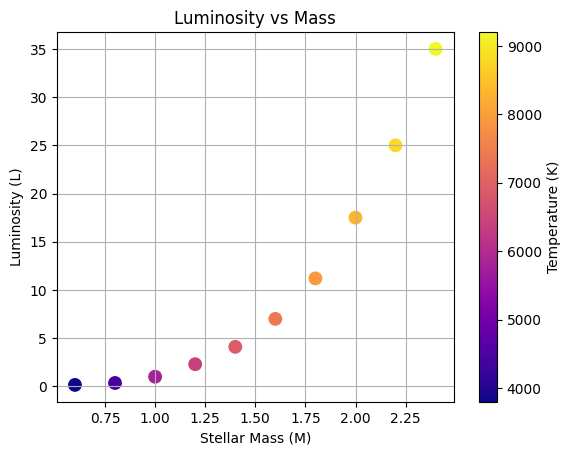

In [41]:
plt.figure()

scatter = plt.scatter(
    M, L,
    c=T,
    cmap='plasma',
    s=80
)

plt.xlabel("Stellar Mass (M)")
plt.ylabel("Luminosity (L)")
plt.title("Luminosity vs Mass")

cbar = plt.colorbar(scatter)
cbar.set_label("Temperature (K)")

plt.grid(True)
plt.show()


In [8]:
def compute_cost(X, L, w, b):
    """Compute the cost J(w,b) for linear regression with multiple features.

    Uses the vectorized formula:
        J = (1 / (2m)) * (y_hat - y)^T (y_hat - y)
    Returns
    -------
    cost : float
    """
    m = X.shape[0]
    L_hat = predict(X, w, b)
    error = L_hat - L
    cost = (error @ error) / (2 * m)
    return cost

In [9]:
def compute_gradient(X, L, w, b):
    """Compute the gradients of J with respect to w and b.

    Vectorized formulas:
        dj_dw = (1/m) * X^T (L_hat - L)
        dj_db = (1/m) * sum(L_hat - L)
    """
    m = X.shape[0]
    L_hat = predict(X, w, b)
    error = L_hat - L

    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

# **4. GRADIENT DESCENT + CONVERGENCE**

In [10]:
def gradient_descent(X, L, w_init, b_init, alpha, num_iterations):
    """Run gradient descent to learn w and b.

    Parameters
    ----------
    X : np.ndarray, shape (m, n)
    L : np.ndarray, shape (m,)
    w_init : np.ndarray, shape (n,)
    b_init : float
    alpha : float
        Learning rate.
    num_iterations : int

    Returns
    -------
    w : np.ndarray, shape (n,)
    b : float
    history_it : list of int
    history_cost : list of float
    """
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i % 10 == 0 or i == num_iterations - 1:
            cost = compute_cost(X, L, w, b)
            history_it.append(i)
            history_cost.append(cost)
            print(f"Iteration {i:4d}: cost = {cost:8.4f}")

    return w, b, history_it, history_cost

alpha = 1e-9
num_iterations = 1000
w_init = np.zeros(X.shape[1])
b_init = 0.0

w_learned, b_learned, it_hist, cost_hist = gradient_descent(X, L, w_init, b_init, alpha, num_iterations)
print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)


Iteration    0: cost =  80.1334
Iteration   10: cost =  19.7645
Iteration   20: cost =  18.3887
Iteration   30: cost =  17.5240
Iteration   40: cost =  16.7139
Iteration   50: cost =  15.9520
Iteration   60: cost =  15.2354
Iteration   70: cost =  14.5613
Iteration   80: cost =  13.9273
Iteration   90: cost =  13.3310
Iteration  100: cost =  12.7700
Iteration  110: cost =  12.2424
Iteration  120: cost =  11.7462
Iteration  130: cost =  11.2794
Iteration  140: cost =  10.8403
Iteration  150: cost =  10.4274
Iteration  160: cost =  10.0389
Iteration  170: cost =   9.6736
Iteration  180: cost =   9.3299
Iteration  190: cost =   9.0067
Iteration  200: cost =   8.7026
Iteration  210: cost =   8.4166
Iteration  220: cost =   8.1476
Iteration  230: cost =   7.8946
Iteration  240: cost =   7.6567
Iteration  250: cost =   7.4328
Iteration  260: cost =   7.2223
Iteration  270: cost =   7.0242
Iteration  280: cost =   6.8380
Iteration  290: cost =   6.6627
Iteration  300: cost =   6.4979
Iteratio

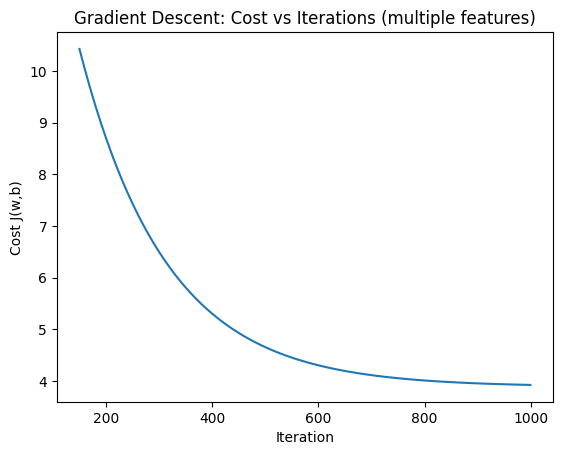

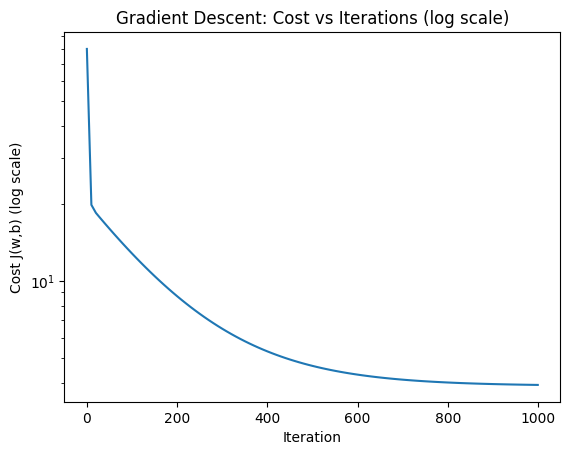

In [11]:
plt.figure()
plt.plot(it_hist[15:], cost_hist[15:])
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Gradient Descent: Cost vs Iterations (multiple features)")
plt.show()

plt.figure()
plt.semilogy(it_hist, cost_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b) (log scale)")
plt.title("Gradient Descent: Cost vs Iterations (log scale)")
plt.show()

# **5. FEATURE SELECTION EXPERIMENT**

In [12]:
def plot_hat_vs_actual(X, L, w, b, title):
    L_hat = predict(X, w, b)

    plt.figure()
    plt.scatter(L, L_hat)
    plt.plot([L.min(), L.max()], [L.min(), L.max()], 'r--')
    plt.xlabel("Actual Luminosity")
    plt.ylabel("Predicted Luminosity")
    plt.title(title)
    plt.grid(True)
    plt.show()


In [13]:
#M1 MATRIX
X_M1 = np.column_stack([M, T])

alpha = 1e-8
num_iterations = 1000
w_init = np.zeros(X_M1.shape[1])
b_init = 0.0

w_learned_m1, b_learned_m1, it_hist_m1, cost_hist_m1 = gradient_descent(X_M1, L, w_init, b_init, alpha, num_iterations)
print("\nLearned parameters:")
print("w =", w_learned_m1)
print("b =", b_learned_m1)

Iteration    0: cost =  59.9813
Iteration   10: cost =  41.1645
Iteration   20: cost =  41.1645
Iteration   30: cost =  41.1645
Iteration   40: cost =  41.1645
Iteration   50: cost =  41.1645
Iteration   60: cost =  41.1645
Iteration   70: cost =  41.1645
Iteration   80: cost =  41.1645
Iteration   90: cost =  41.1645
Iteration  100: cost =  41.1645
Iteration  110: cost =  41.1645
Iteration  120: cost =  41.1645
Iteration  130: cost =  41.1645
Iteration  140: cost =  41.1645
Iteration  150: cost =  41.1645
Iteration  160: cost =  41.1645
Iteration  170: cost =  41.1645
Iteration  180: cost =  41.1645
Iteration  190: cost =  41.1645
Iteration  200: cost =  41.1645
Iteration  210: cost =  41.1645
Iteration  220: cost =  41.1645
Iteration  230: cost =  41.1645
Iteration  240: cost =  41.1645
Iteration  250: cost =  41.1645
Iteration  260: cost =  41.1645
Iteration  270: cost =  41.1645
Iteration  280: cost =  41.1645
Iteration  290: cost =  41.1645
Iteration  300: cost =  41.1645
Iteratio

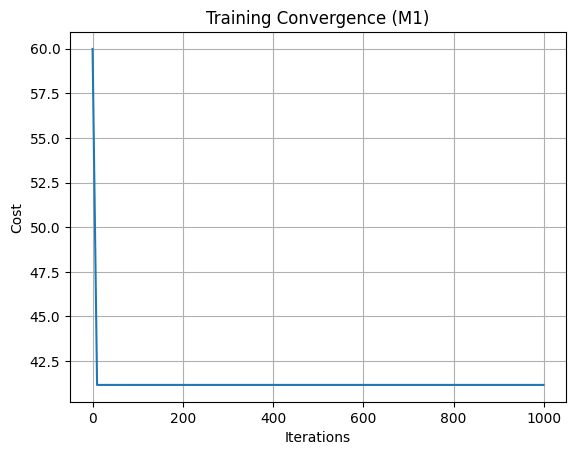

In [14]:
plt.figure()
plt.plot(it_hist_m1, cost_hist_m1)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Convergence (M1)")
plt.grid(True)
plt.show()


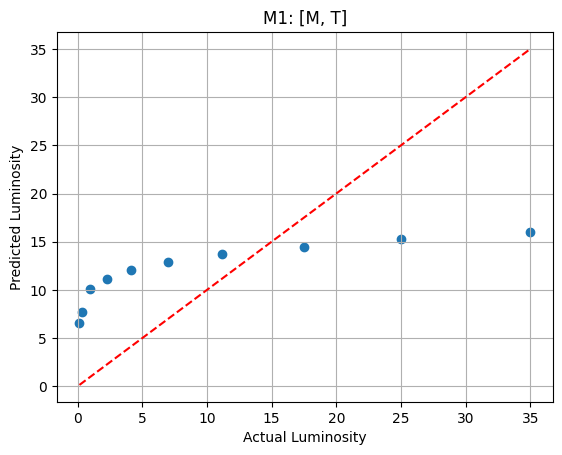

In [15]:
plot_hat_vs_actual(X_M1, L, w_learned_m1, b_learned_m1, "M1: [M, T]")

In [16]:
#M2 MATRIX
X_M2 = np.column_stack([M, T, M2])

alpha = 1e-8
num_iterations = 1000
w_init = np.zeros(X_M2.shape[1])
b_init = 0.0

w_learned_m2, b_learned_m2, it_hist_m2, cost_hist_m2 = gradient_descent(X_M2, L, w_init, b_init, alpha, num_iterations)
print("\nLearned parameters:")
print("w =", w_learned_m2)
print("b =", b_learned_m2)

Iteration    0: cost =  59.9813
Iteration   10: cost =  41.1645
Iteration   20: cost =  41.1645
Iteration   30: cost =  41.1645
Iteration   40: cost =  41.1645
Iteration   50: cost =  41.1645
Iteration   60: cost =  41.1645
Iteration   70: cost =  41.1644
Iteration   80: cost =  41.1644
Iteration   90: cost =  41.1644
Iteration  100: cost =  41.1644
Iteration  110: cost =  41.1644
Iteration  120: cost =  41.1644
Iteration  130: cost =  41.1644
Iteration  140: cost =  41.1644
Iteration  150: cost =  41.1644
Iteration  160: cost =  41.1643
Iteration  170: cost =  41.1643
Iteration  180: cost =  41.1643
Iteration  190: cost =  41.1643
Iteration  200: cost =  41.1643
Iteration  210: cost =  41.1643
Iteration  220: cost =  41.1643
Iteration  230: cost =  41.1643
Iteration  240: cost =  41.1643
Iteration  250: cost =  41.1643
Iteration  260: cost =  41.1642
Iteration  270: cost =  41.1642
Iteration  280: cost =  41.1642
Iteration  290: cost =  41.1642
Iteration  300: cost =  41.1642
Iteratio

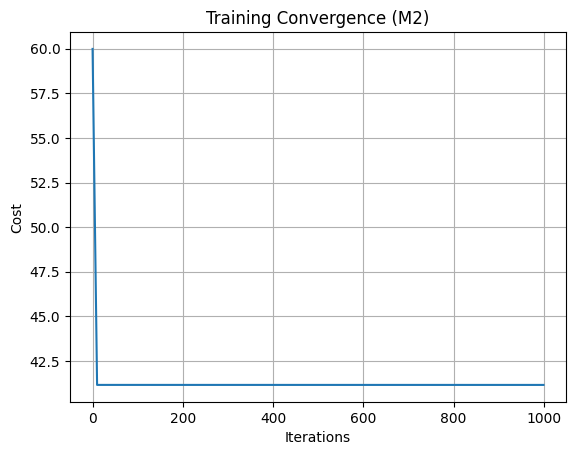

In [17]:
plt.figure()
plt.plot(it_hist_m2, cost_hist_m2)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Convergence (M2)")
plt.grid(True)
plt.show()

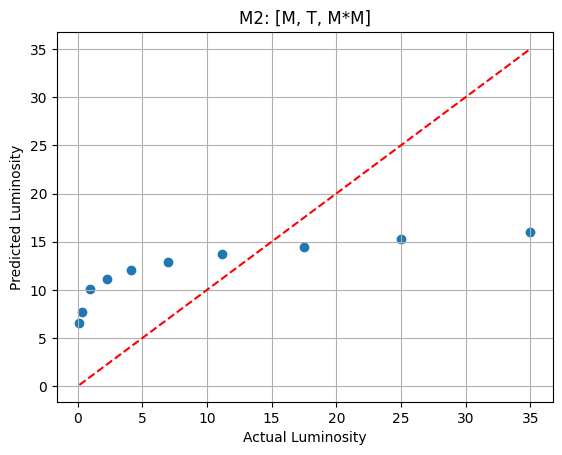

In [18]:
plot_hat_vs_actual(X_M2, L, w_learned_m2, b_learned_m2, "M2: [M, T, M*M]")

In [19]:
#M3 MATRIX
X_M3 = np.column_stack([M, T, M2, MT])

alpha = 1e-9
num_iterations = 1000
w_init = np.zeros(X_M3.shape[1])
b_init = 0.0

w_learned_m3, b_learned_m3, it_hist_m3, cost_hist_m3 = gradient_descent(X_M3, L, w_init, b_init, alpha, num_iterations)
print("\nLearned parameters:")
print("w =", w_learned_m3)
print("b =", b_learned_m3)

Iteration    0: cost =  80.1334
Iteration   10: cost =  19.7645
Iteration   20: cost =  18.3887
Iteration   30: cost =  17.5240
Iteration   40: cost =  16.7139
Iteration   50: cost =  15.9520
Iteration   60: cost =  15.2354
Iteration   70: cost =  14.5613
Iteration   80: cost =  13.9273
Iteration   90: cost =  13.3310
Iteration  100: cost =  12.7700
Iteration  110: cost =  12.2424
Iteration  120: cost =  11.7462
Iteration  130: cost =  11.2794
Iteration  140: cost =  10.8403
Iteration  150: cost =  10.4274
Iteration  160: cost =  10.0389
Iteration  170: cost =   9.6736
Iteration  180: cost =   9.3299
Iteration  190: cost =   9.0067
Iteration  200: cost =   8.7026
Iteration  210: cost =   8.4166
Iteration  220: cost =   8.1476
Iteration  230: cost =   7.8946
Iteration  240: cost =   7.6567
Iteration  250: cost =   7.4328
Iteration  260: cost =   7.2223
Iteration  270: cost =   7.0242
Iteration  280: cost =   6.8380
Iteration  290: cost =   6.6627
Iteration  300: cost =   6.4979
Iteratio

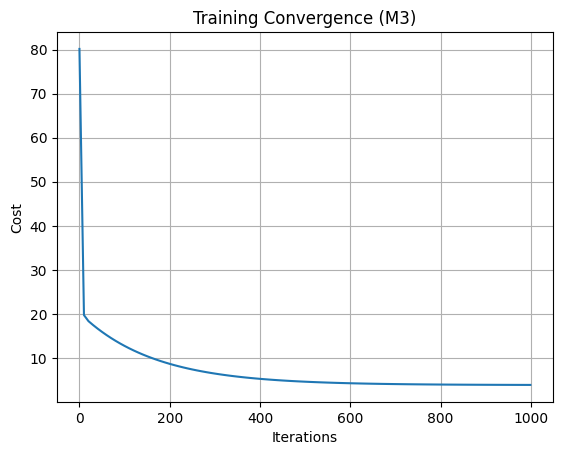

In [20]:
plt.figure()
plt.plot(it_hist_m3, cost_hist_m3)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Convergence (M3)")
plt.grid(True)
plt.show()

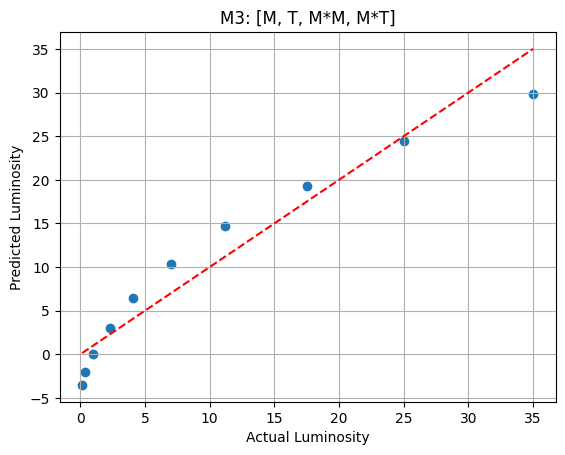

In [21]:
plot_hat_vs_actual(X_M3, L, w_learned_m3, b_learned_m3, "M3: [M, T, M*M, M*T]")

# 5. **COST VS INTERACTION**

In [33]:
w_MT = w_learned_m3[3]
print("w_MT:", w_MT)

#LIST OF w_MT VARIATIONS
w_MT_values = np.linspace(
    w_learned_m3[3] - 0.3, #FROM
    w_learned_m3[3] + 0.3, #TO
    100) #QUANTITY

costs = []

for w_mt in w_MT_values:
    w_temp = w_learned_m3.copy()
    w_temp[3] = w_mt   # CHANGE w_MT

    cost = compute_cost(X_M3, L, w_temp, b_learned_m3)
    costs.append(cost)



w_MT: 0.0023145613358966674


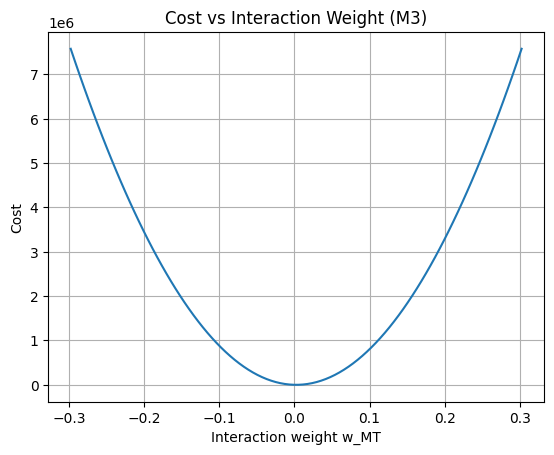

In [34]:
plt.figure()
plt.plot(w_MT_values, costs)
plt.xlabel("Interaction weight w_MT")
plt.ylabel("Cost")
plt.title("Cost vs Interaction Weight (M3)")
plt.grid(True)
plt.show()


The shape of the cost curve shows that the MT interaction strongly influences the luminosity prediction, indicating a high interaction.

# 6. **INFERENCE DEMO**

In [22]:
M_new = 1.3
T_new = 6600

X_new = np.array([[M_new, T_new, M_new**2, M_new*T_new]])
L_pred = predict(X_new, w_learned_m3, b_learned_m3)

print("Predicted luminosity:", L_pred)


Predicted luminosity: [4.6021]


Using the trained polynomial model (M3), a luminosity of approximately 4.60 is predicted. Based on the dataset, we can say that this is a reasonable result, as there are stars of approximately the same size and temperature that have a similar luminosity.